In [31]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Step 1: Load the data
data = fetch_california_housing(as_frame=True)
df = data.frame

In [5]:
df.iloc[5:10]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [9]:
df.duplicated().sum()

0

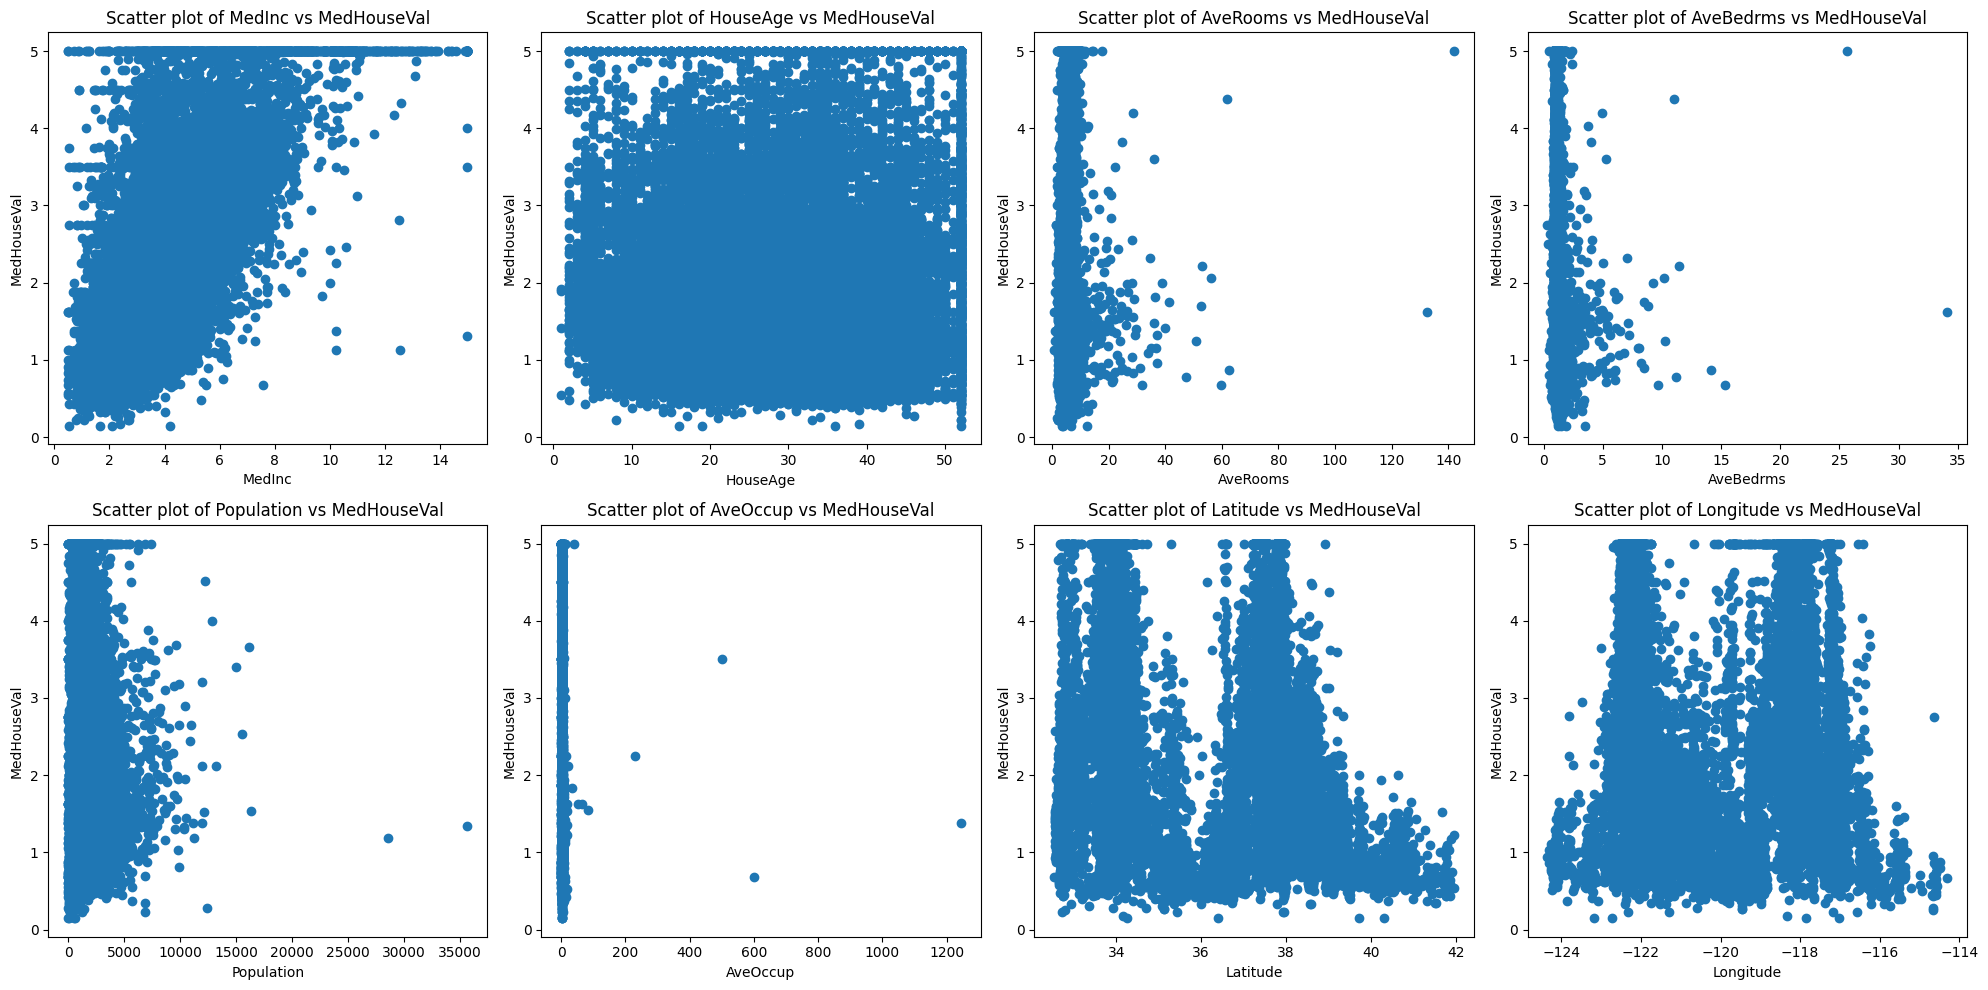

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()  # Flatten the axes array for easier iteration

for i, col in enumerate(df.columns):
    if col != 'MedHouseVal' and i < 8:  # Limit to 8 subplots
        axes[i].scatter(df[col], df['MedHouseVal'])
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('MedHouseVal')
        axes[i].set_title(f'Scatter plot of {col} vs MedHouseVal')

plt.tight_layout() # Adjust spacing between subplots
plt.show()

In [11]:
#outlier detection by the z-score method
z_scores = np.abs(stats.zscore(df.iloc[:, :-1]))
threshold = 3  # Z-score threshold (common threshold: 3)
outliers_z = (z_scores > threshold)

# Outlier Detection using IQR Method
Q1 = df.iloc[:, :-1].quantile(0.25)
Q3 = df.iloc[:, :-1].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((df.iloc[:, :-1] < (Q1 - 1.5 * IQR)) | (df.iloc[:, :-1] > (Q3 + 1.5 * IQR)))

# Combine the outlier results
outliers_combined = outliers_z | outliers_iqr

#Remove Outliers: Here we remove rows with outliers from any of the features
df_cleaned = df[~outliers_combined.any(axis=1)]

# Display the number of outliers removed
print(f"Number of outliers removed: {len(df) - len(df_cleaned)}")

Number of outliers removed: 3798


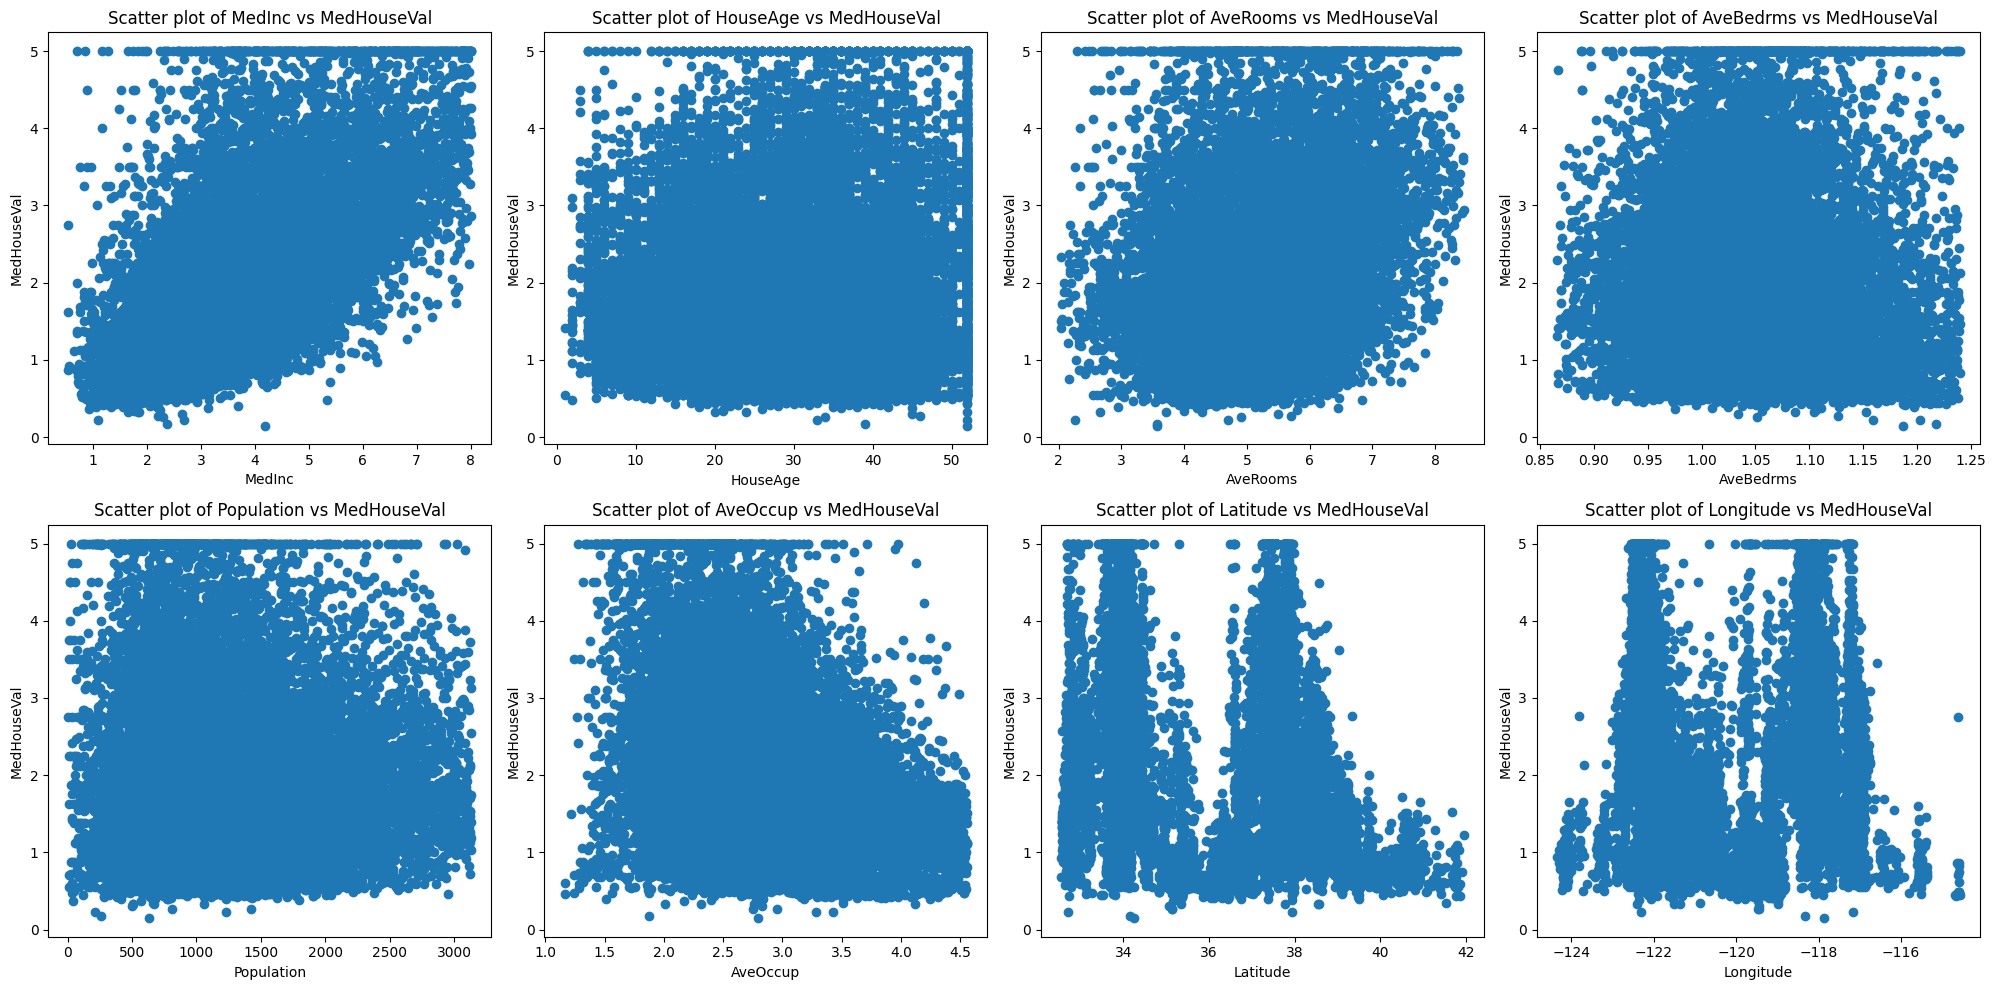

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()  # Flatten the axes array for easier iteration

for i, col in enumerate(df_cleaned.columns):
    if col != 'MedHouseVal' and i < 8:  # Limit to 8 subplots
        axes[i].scatter(df_cleaned[col], df_cleaned['MedHouseVal'])
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('MedHouseVal')
        axes[i].set_title(f'Scatter plot of {col} vs MedHouseVal')

plt.tight_layout() # Adjust spacing between subplots
plt.show()

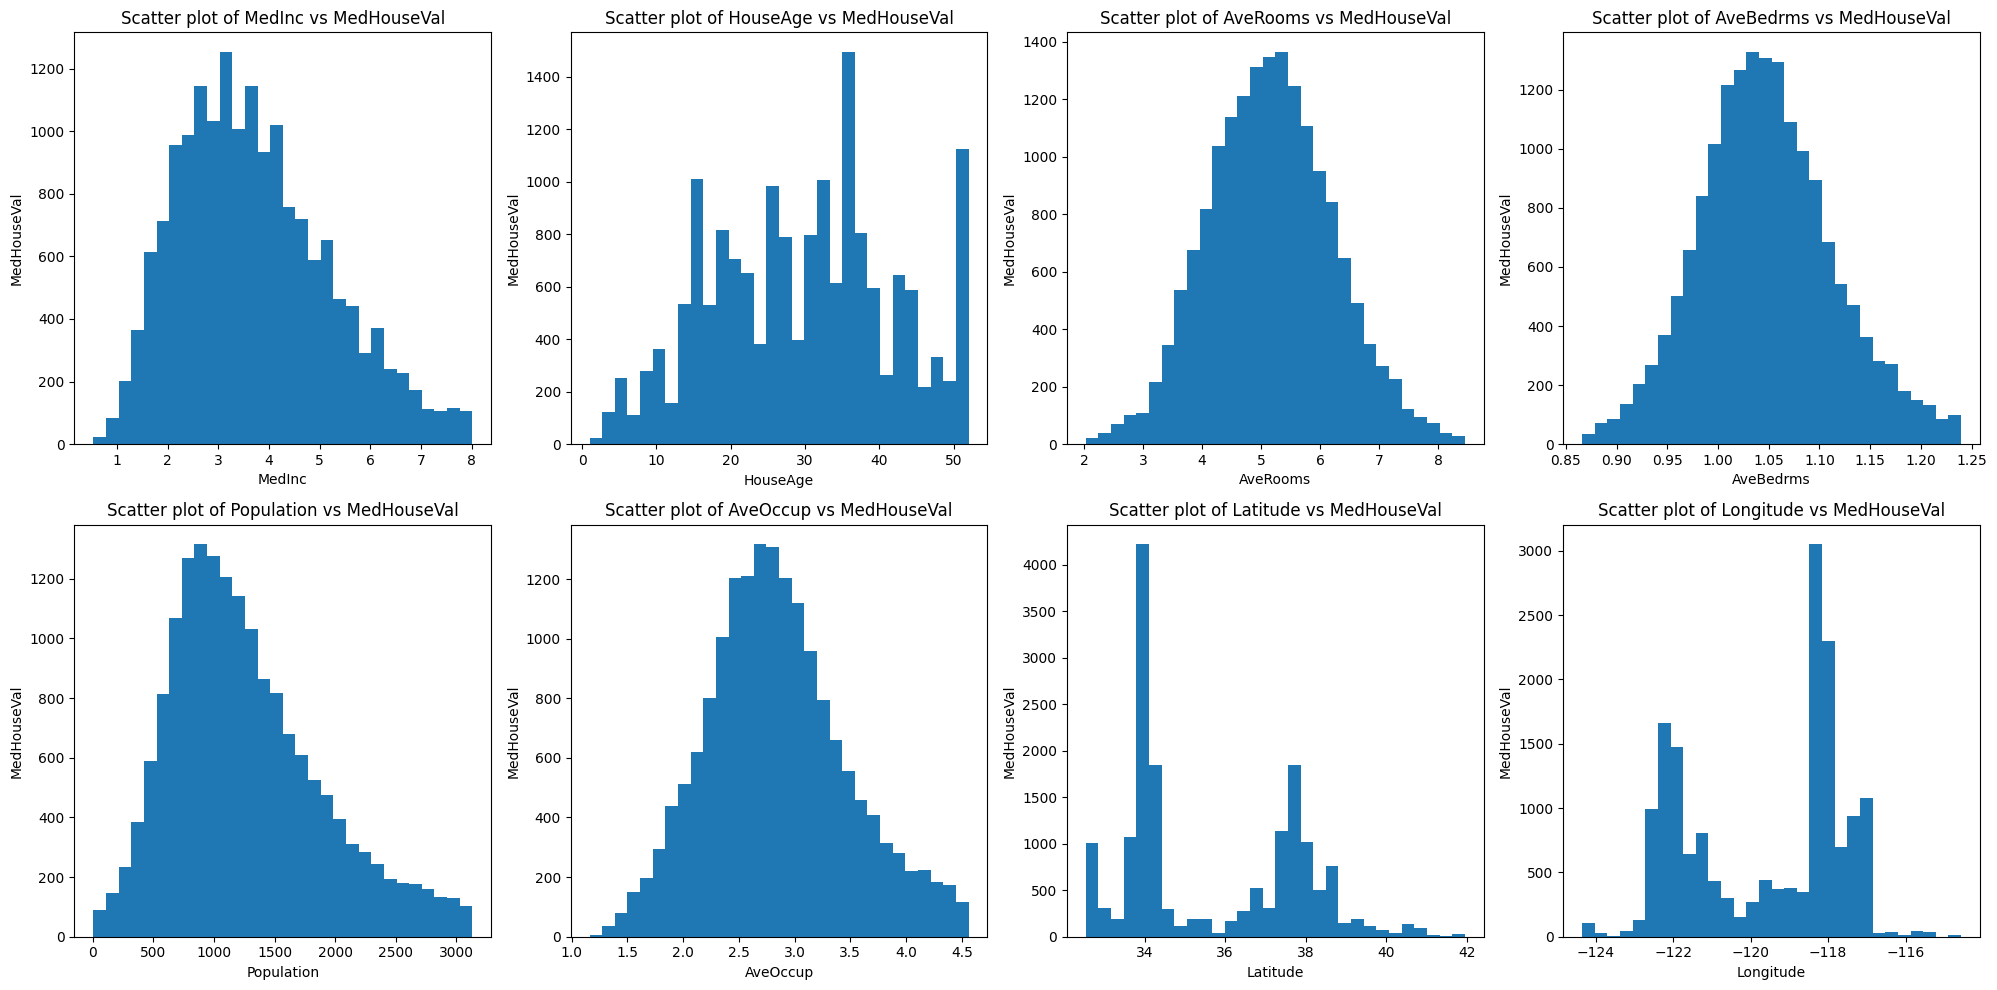

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()  # Flatten the axes array for easier iteration

for i, col in enumerate(df_cleaned.columns):
    if col != 'MedHouseVal' and i < 8:  # Limit to 8 subplots
        axes[i].hist(df_cleaned[col], bins=30)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('MedHouseVal')
        axes[i].set_title(f'Scatter plot of {col} vs MedHouseVal')

plt.tight_layout() # Adjust spacing between subplots
plt.show()

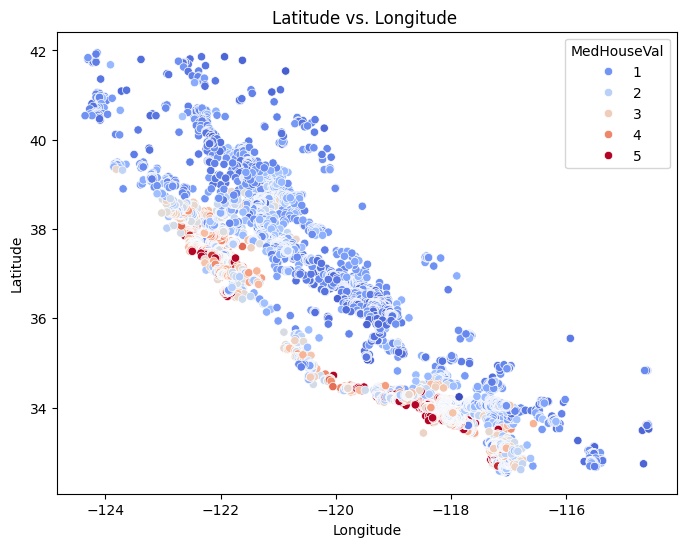

In [14]:
# 'Latitude', 'Longitude', and 'MedHouseVal'  as hue.
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cleaned, x='Longitude', y='Latitude', hue='MedHouseVal', palette='coolwarm')
plt.title('Latitude vs. Longitude ')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

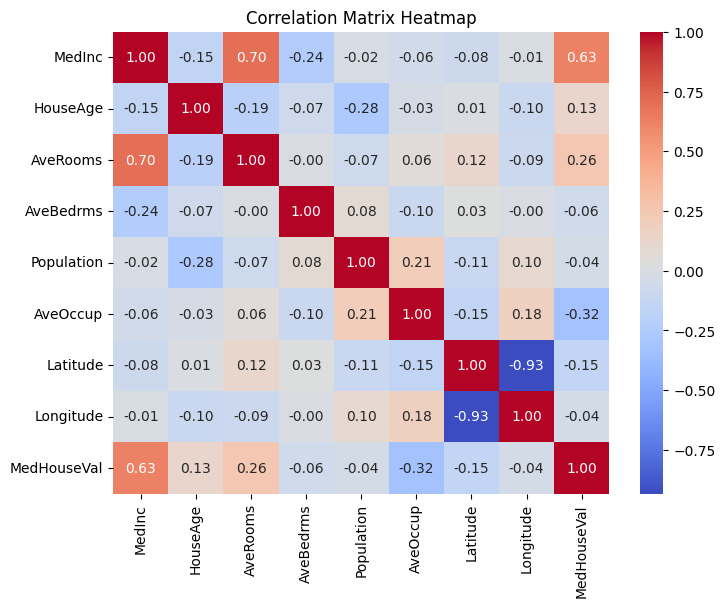

In [15]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

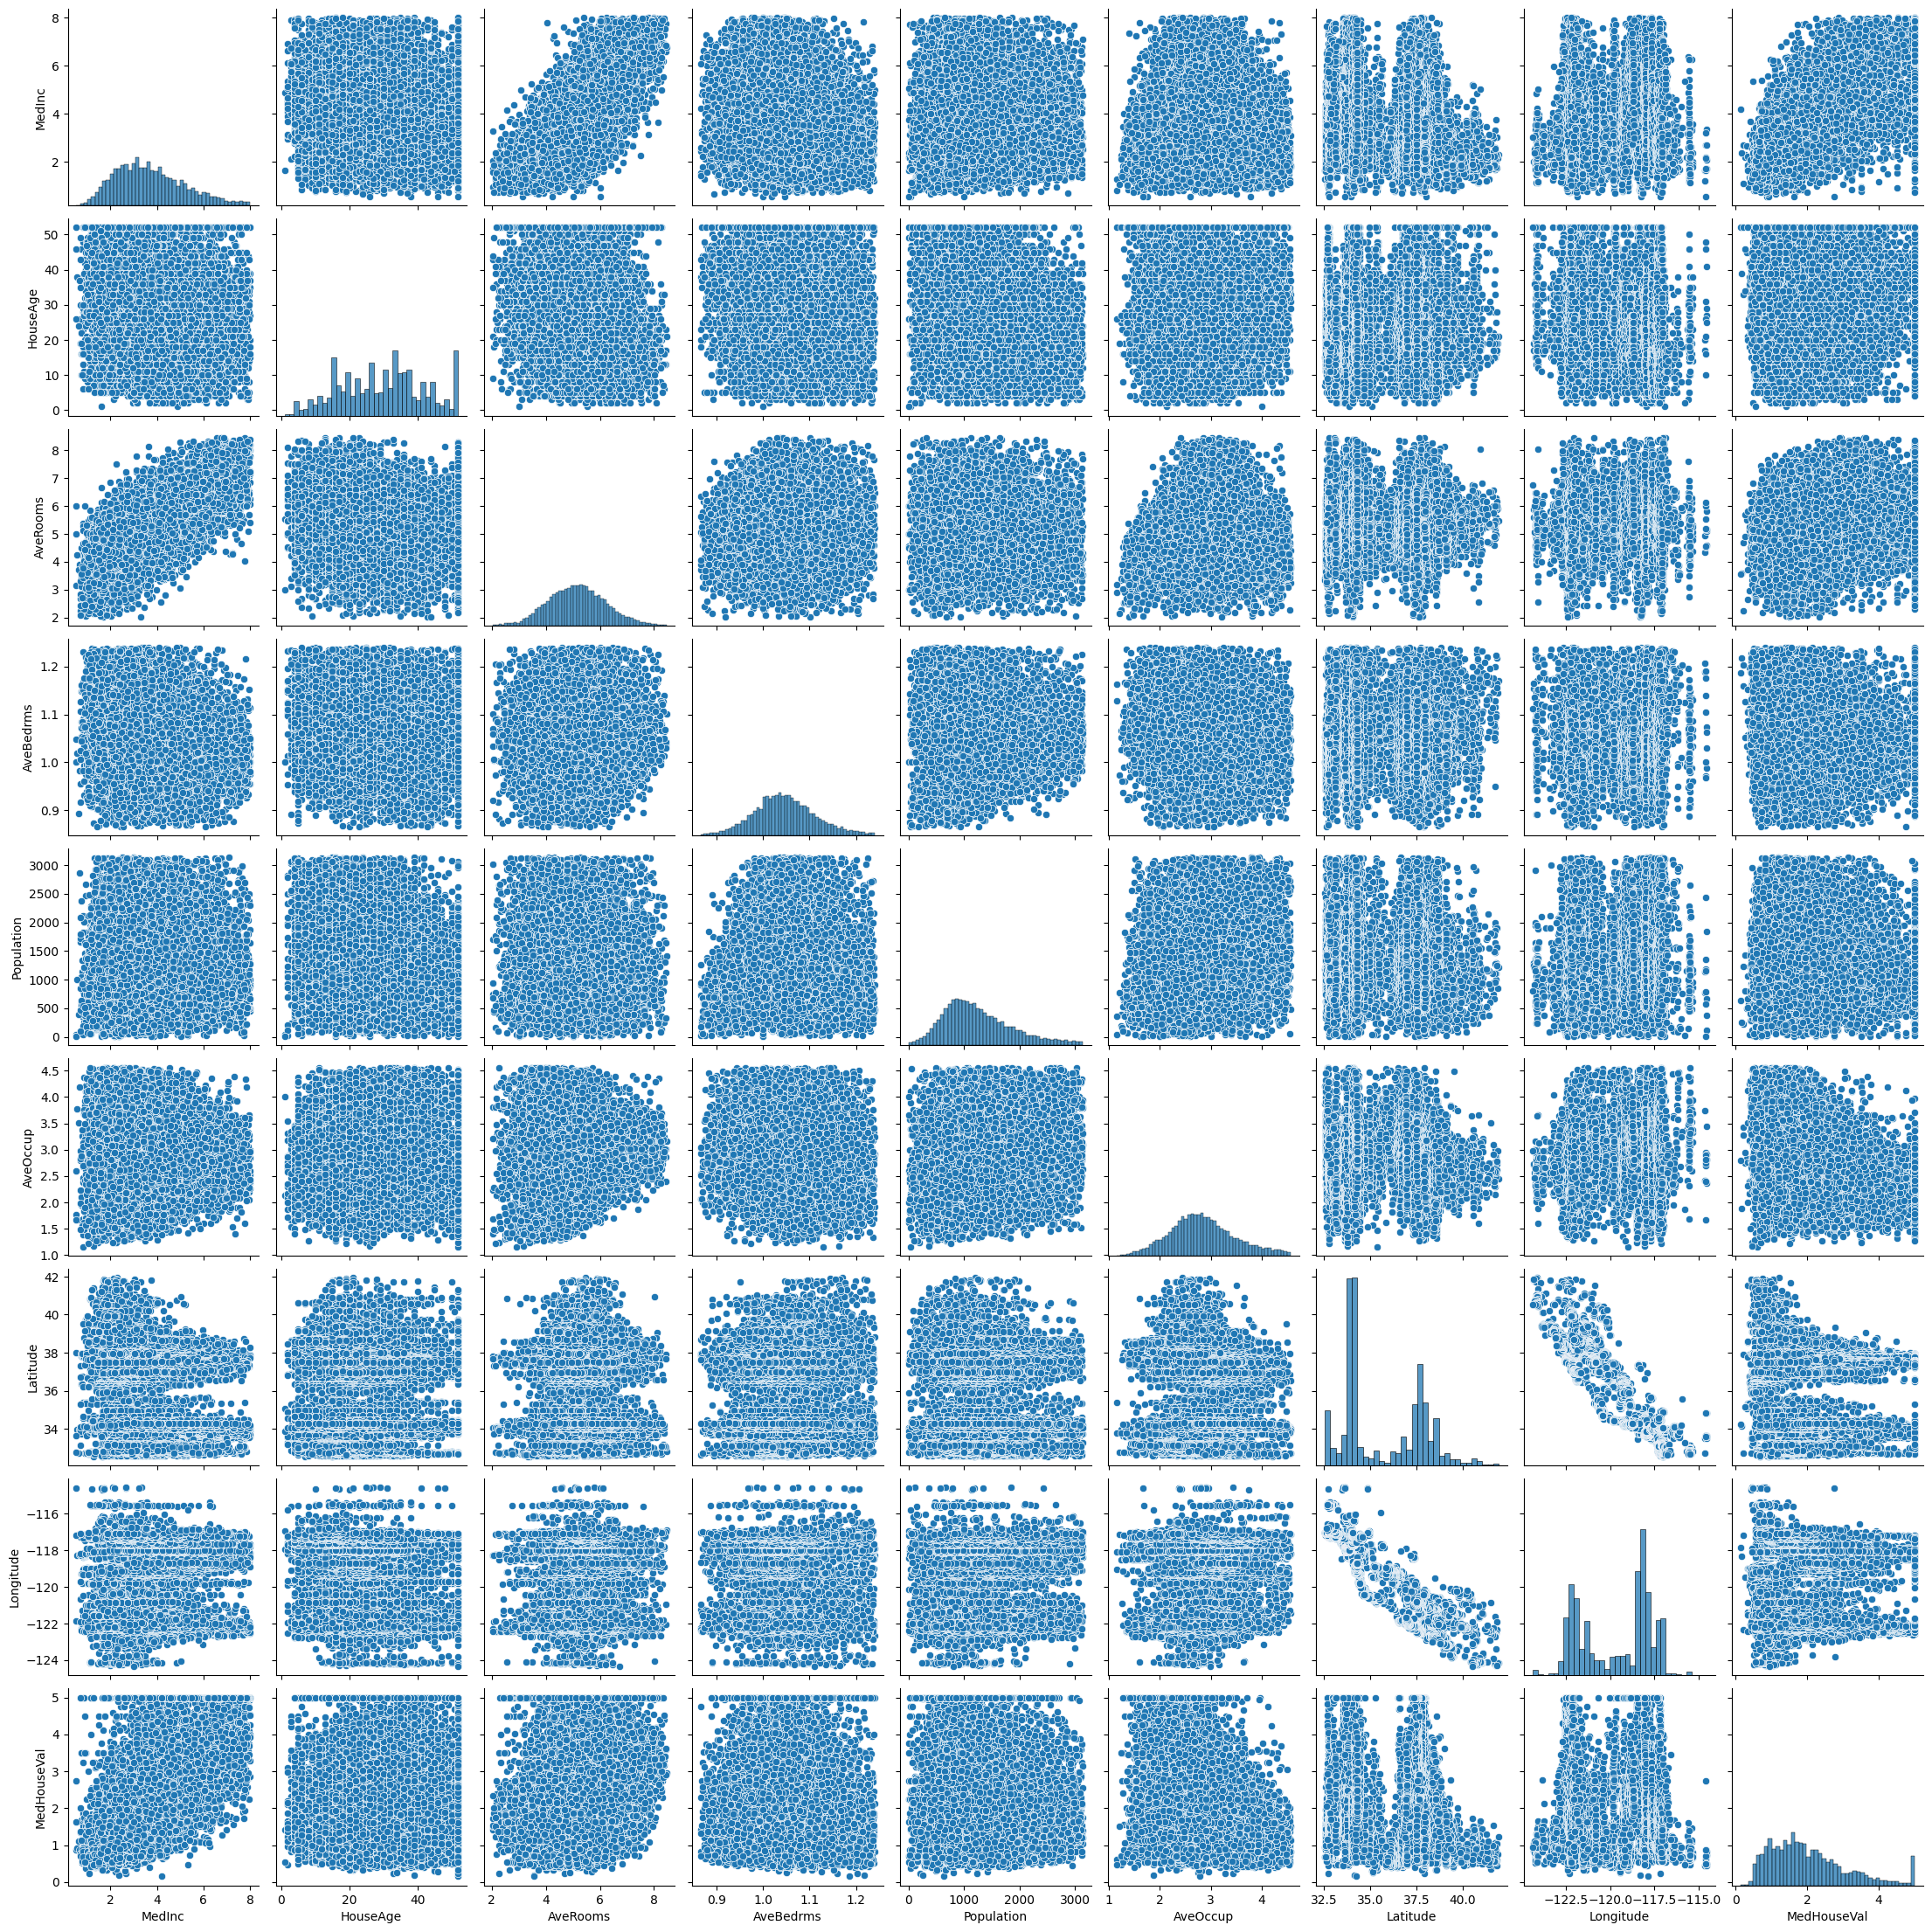

In [16]:
sns.pairplot(df_cleaned)
plt.show()

In [17]:
features = df_cleaned.drop('MedHouseVal', axis=1)
target = df_cleaned['MedHouseVal']

In [18]:
# Feature Engineering

# Scaling the features using StandardScaler (Normalization)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [19]:
# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
features_poly = poly.fit_transform(features_scaled)
# Displaying a few polynomial features (first 5 rows)
print(f"Polynomial Features: \n{features_poly[:5, :]}")

Polynomial Features: 
[[ 2.39005827e+00  1.82111032e+00  2.96008066e+00  3.84216535e-01
  -1.22819754e+00 -6.72766709e-02  1.02869439e+00 -1.30893217e+00
   5.71237854e+00  4.35255979e+00  7.07476526e+00  9.18299907e-01
  -2.93546369e+00 -1.60795164e-01  2.45863953e+00 -3.12842416e+00
   3.31644280e+00  5.39063344e+00  6.99700697e-01 -2.23668321e+00
  -1.22518240e-01  1.87336597e+00 -2.38370988e+00  8.76207750e+00
   1.13731193e+00 -3.63556378e+00 -1.99144372e-01  3.04501836e+00
  -3.87454480e+00  1.47622346e-01 -4.71893802e-01 -2.58488094e-02
   3.95241394e-01 -5.02913382e-01  1.50846920e+00  8.26290417e-02
  -1.26343992e+00  1.60762727e+00  4.52615045e-03 -6.92071339e-02
   8.80605988e-02  1.05821215e+00 -1.34649118e+00  1.71330342e+00]
 [ 1.30138302e+00  1.82111032e+00  6.14838818e-01  3.78410917e-01
  -1.12911167e+00 -4.70506200e-01  1.02869439e+00 -1.31394749e+00
   1.69359777e+00  2.36996205e+00  8.00140799e-01  4.92457543e-01
  -1.46940676e+00 -6.12308781e-01  1.33872541e+00 -1.

In [20]:
# Using Recursive Feature Elimination (RFE) with Linear Regression as the estimator
selector = RFE(estimator=LinearRegression(), n_features_to_select=10)  # Selecting top 10 features
features_selected = selector.fit_transform(features_poly, target)

ploy_feature_names = poly.get_feature_names_out(features.columns)

# Displaying the selected features
selected_columns = np.array(ploy_feature_names)[selector.support_]
print(f"Selected Features after RFE: {selected_columns}")

Selected Features after RFE: ['MedInc' 'AveOccup' 'Latitude' 'Longitude' 'MedInc Latitude'
 'MedInc Longitude' 'HouseAge Latitude' 'HouseAge Longitude'
 'AveRooms Latitude' 'AveRooms Longitude']


In [21]:
# Step 4: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features_selected, target, test_size=0.2, random_state=42)


In [22]:
# Helper function for model evaluation
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [54]:
# Store results in DataFrame
results_df = pd.DataFrame(columns=['Model', 'Train MAE', 'Train MSE', 'Train RMSE', 'Train R^2', 'Test MAE', 'Test MSE', 'Test RMSE', 'Test R^2'])


In [55]:
# ------------------- Linear Regression -------------------
# Initialize model
linear_model = LinearRegression()

# Training the model
linear_model.fit(X_train, y_train)

# Testing the model
y_train_pred_lr = linear_model.predict(X_train)
y_test_pred_lr = linear_model.predict(X_test)

# Evaluate performance
train_mae_lr, train_mse_lr, train_rmse_lr, train_r2_lr = evaluate_model(y_train, y_train_pred_lr)
test_mae_lr, test_mse_lr, test_rmse_lr, test_r2_lr = evaluate_model(y_test, y_test_pred_lr)

# Cross-validation (Linear Regression)
cv_lr = cross_val_score(linear_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("The cross validation scores:",cv_lr)
cv_lr_mse = -cv_lr.mean()  # convert from negative MSE to positive
print("The cross validation mean:",cv_lr_mse)

# Store results using pd.concat instead of append
new_row = pd.DataFrame([{
    'Model': 'Linear Regression',
    'Train MAE': train_mae_lr,
    'Train MSE': train_mse_lr,
    'Train RMSE': train_rmse_lr,
    'Train R^2': train_r2_lr,
    'Test MAE': test_mae_lr,
    'Test MSE': test_mse_lr,
    'Test RMSE': test_rmse_lr,
    'Test R^2': test_r2_lr
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df.head()

The cross validation scores: [-0.41077525 -0.4295693  -0.41072579 -0.40534711 -0.38853776]
The cross validation mean: 0.4089910407926395


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,0.468919,0.408006,0.638753,0.645434,0.479537,0.421382,0.649139,0.630569


In [56]:
# ------------------- Lasso Regression -------------------
# Initialize model
lasso_model = Lasso()

# Training the model
lasso_model.fit(X_train, y_train)

# Testing the model
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

# Evaluate performance
train_mae_lasso, train_mse_lasso, train_rmse_lasso, train_r2_lasso = evaluate_model(y_train, y_train_pred_lasso)
test_mae_lasso, test_mse_lasso, test_rmse_lasso, test_r2_lasso = evaluate_model(y_test, y_test_pred_lasso)

# Cross-validation (Lasso)
cv_lasso = cross_val_score(lasso_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("The cross validation scores: ",cv_lasso)
cv_lasso_mean= -cv_lasso.mean()  # convert from negative MSE to positive
print("The cross validation mean: ",cv_lasso_mean)
# Store results using pd.concat instead of append
new_row = pd.DataFrame([{
    'Model': 'Lasso Regression',
    'Train MAE': train_mae_lasso,
    'Train MSE': train_mse_lasso,
    'Train RMSE': train_rmse_lasso,
    'Train R^2': train_r2_lasso,
    'Test MAE': test_mae_lasso,
    'Test MSE': test_mse_lasso,
    'Test RMSE': test_rmse_lasso,
    'Test R^2': test_r2_lasso
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df.head()

The cross validation scores:  [-1.17381826 -1.19128079 -1.12447129 -1.13442909 -1.13045034]
The cross validation mean:  1.1508899545984435


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,0.468919,0.408006,0.638753,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,0.847466,1.150720,1.072716,0.000000,0.845521,1.140672,1.068022,-0.000041


In [57]:
# ------------------- Decision Tree Regressor -------------------
# Initialize model
dt_model = DecisionTreeRegressor()

#Training
dt_model.fit(X_train, y_train)

# Testing the model
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Evaluate performance
train_mae_dt, train_mse_dt, train_rmse_dt, train_r2_dt = evaluate_model(y_train, y_train_pred_dt)
test_mae_dt, test_mse_dt, test_rmse_dt, test_r2_dt = evaluate_model(y_test, y_test_pred_dt)

# Store results
new_row = pd.DataFrame([{
    'Model': 'Decision Tree Regressor',
    'Train MAE': train_mae_dt,
    'Train MSE': train_mse_dt,
    'Train RMSE': train_rmse_dt,
    'Train R^2': train_r2_dt,
    'Test MAE': test_mae_dt,
    'Test MSE': test_mse_dt,
    'Test RMSE': test_rmse_dt,
    'Test R^2': test_r2_dt
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df.head()

,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961


In [58]:
# ------------------- Decision Tree Regressor with Grid Search -------------------


# Hyperparameter tuning using GridSearchCV
param_dist_dt = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}
grid_search_dt = GridSearchCV(dt_model, param_dist_dt, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

# Best estimator from random search
best_dt_model = grid_search_dt.best_estimator_
print("\nBest Parameters for Decision Tree Regressor:", grid_search_dt.best_params_)

# Training the model with the best parameters
best_dt_model.fit(X_train, y_train)

# Testing the model
y_train_pred_dt_gs = best_dt_model.predict(X_train)
y_test_pred_dt_gs = best_dt_model.predict(X_test)

# Evaluate performance
train_mae_dt_gs, train_mse_dt_gs, train_rmse_dt_gs, train_r2_dt_gs = evaluate_model(y_train, y_train_pred_dt_gs)
test_mae_dt_gs, test_mse_dt_gs, test_rmse_dt_gs, test_r2_dt_gs = evaluate_model(y_test, y_test_pred_dt_gs)

# Store results
new_row = pd.DataFrame([{
    'Model': 'Decision Tree Regressor with Grid Search',
    'Train MAE': train_mae_dt_gs,
    'Train MSE': train_mse_dt_gs,
    'Train RMSE': train_rmse_dt_gs,
    'Train R^2': train_r2_dt_gs,
    'Test MAE': test_mae_dt_gs,
    'Test MSE': test_mse_dt_gs,
    'Test RMSE': test_rmse_dt_gs,
    'Test R^2': test_r2_dt_gs
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df.head()


Best Parameters for Decision Tree Regressor: {'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 5}


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961
3,Decision Tree Regressor with Grid Search,2.670463e-01,1.637967e-01,4.047181e-01,0.857657,0.374344,0.327965,0.572683,0.712469


In [59]:
# ------------------- Random Forest Regressor -------------------
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Testing the model
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate performance
train_mae_rf, train_mse_rf, train_rmse_rf, train_r2_rf = evaluate_model(y_train, y_train_pred_rf)
test_mae_rf, test_mse_rf, test_rmse_rf, test_r2_rf = evaluate_model(y_test, y_test_pred_rf)
# Store results
new_row = pd.DataFrame([{
    'Model': 'Random Forest Regressor',
    'Train MAE': train_mae_rf,
    'Train MSE': train_mse_rf,
    'Train RMSE': train_rmse_rf,
    'Train R^2': train_r2_rf,
    'Test MAE': test_mae_rf,
    'Test MSE': test_mse_rf,
    'Test RMSE': test_rmse_rf,
    'Test R^2': test_r2_rf
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961
3,Decision Tree Regressor with Grid Search,2.670463e-01,1.637967e-01,4.047181e-01,0.857657,0.374344,0.327965,0.572683,0.712469
4,Random Forest Regressor,1.148185e-01,3.098924e-02,1.760376e-01,0.973070,0.316555,0.237465,0.487304,0.791811


In [60]:

# Hyperparameter tuning using RandomizedSearchCV with the specified parameter grid
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],  # Replace 'auto' with 'sqrt' or 'log2'
    'bootstrap': [True, False]
}
random_search_rf = RandomizedSearchCV(rf_model, param_dist_rf, n_iter=10, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
random_search_rf.fit(X_train, y_train)

# Best estimator from random search
best_rf_model = random_search_rf.best_estimator_
print("\nBest Parameters for Random Forest Regressor:", random_search_rf.best_params_)

# Training the model with the best parameters
best_rf_model.fit(X_train, y_train)

# Testing the model
y_train_pred_rf_rs = best_rf_model.predict(X_train)
y_test_pred_rf_rs = best_rf_model.predict(X_test)

# Evaluate performance
train_mae_rf_rs, train_mse_rf_rs, train_rmse_rf_rs, train_r2_rf_rs = evaluate_model(y_train, y_train_pred_rf_rs)
test_mae_rf_rs, test_mse_rf_rs, test_rmse_rf_rs, test_r2_rf_rs = evaluate_model(y_test, y_test_pred_rf_rs)
# Store results
new_row = pd.DataFrame([{
    'Model': 'Random Forest Regressor With Random Search',
    'Train MAE': train_mae_rf_rs,
    'Train MSE': train_mse_rf_rs,
    'Train RMSE': train_rmse_rf_rs,
    'Train R^2': train_r2_rf_rs,
    'Test MAE': test_mae_rf_rs,
    'Test MSE': test_mse_rf_rs,
    'Test RMSE': test_rmse_rf_rs,
    'Test R^2': test_r2_rf_rs
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df



Best Parameters for Random Forest Regressor: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': False}


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961
3,Decision Tree Regressor with Grid Search,2.670463e-01,1.637967e-01,4.047181e-01,0.857657,0.374344,0.327965,0.572683,0.712469
4,Random Forest Regressor,1.148185e-01,3.098924e-02,1.760376e-01,0.973070,0.316555,0.237465,0.487304,0.791811
5,Random Forest Regressor With Random Search,4.257893e-02,5.285530e-03,7.270165e-02,0.995407,0.316026,0.231986,0.481649,0.796615


In [62]:
# ------------------- XGBoost Regressor -------------------
xgb_model = XGBRegressor()

#Training
xgb_model.fit(X_train, y_train)

# Testing the model
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
train_mae_xgb, train_mse_xgb, train_rmse_xgb, train_r2_xgb = evaluate_model(y_train, y_train_pred_xgb)
test_mae_xgb, test_mse_xgb, test_rmse_xgb, test_r2_xgb = evaluate_model(y_test, y_test_pred_xgb)

# Store results
new_row = pd.DataFrame([{
    'Model': 'XGBoost Regressor',
    'Train MAE': train_mae_xgb,
    'Train MSE': train_mse_xgb,
    'Train RMSE': train_rmse_xgb,
    'Train R^2': train_r2_xgb,
    'Test MAE': test_mae_xgb,
    'Test MSE': test_mse_xgb,
    'Test RMSE': test_rmse_xgb,
    'Test R^2': test_r2_xgb
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961
3,Decision Tree Regressor with Grid Search,2.670463e-01,1.637967e-01,4.047181e-01,0.857657,0.374344,0.327965,0.572683,0.712469
4,Random Forest Regressor,1.148185e-01,3.098924e-02,1.760376e-01,0.973070,0.316555,0.237465,0.487304,0.791811
5,Random Forest Regressor With Random Search,4.257893e-02,5.285530e-03,7.270165e-02,0.995407,0.316026,0.231986,0.481649,0.796615
6,XGBoost Regressor,1.787219e-01,6.367581e-02,2.523407e-01,0.944664,0.310606,0.215718,0.464454,0.810878


In [63]:
# ------------------- XGBoost Regressor with Random Serach -------------------


# Hyperparameter tuning using RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}
random_search_xgb = RandomizedSearchCV(xgb_model, param_dist_xgb, n_iter=10, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
random_search_xgb.fit(X_train, y_train)

# Best estimator from random search
best_xgb_model = random_search_xgb.best_estimator_
print("\nBest Parameters for XGBoost Regressor:", random_search_xgb.best_params_)

# Training the model with the best parameters
best_xgb_model.fit(X_train, y_train)

# Testing the model
y_train_pred_xgb_rs = best_xgb_model.predict(X_train)
y_test_pred_xgb_rs = best_xgb_model.predict(X_test)

# Evaluate performance
train_mae_xgb_rs, train_mse_xgb_rs, train_rmse_xgb_rs, train_r2_xgb_rs = evaluate_model(y_train, y_train_pred_xgb_rs)
test_mae_xgb_rs, test_mse_xgb_rs, test_rmse_xgb_rs, test_r2_xgb_rs = evaluate_model(y_test, y_test_pred_xgb_rs)

# Store results
new_row = pd.DataFrame([{
    'Model': 'XGBoost Regressor With Random Search',
    'Train MAE': train_mae_xgb_rs,
    'Train MSE': train_mse_xgb_rs,
    'Train RMSE': train_rmse_xgb_rs,
    'Train R^2': train_r2_xgb_rs,
    'Test MAE': test_mae_xgb_rs,
    'Test MSE': test_mse_xgb_rs,
    'Test RMSE': test_rmse_xgb_rs,
    'Test R^2': test_r2_xgb_rs
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df



Best Parameters for XGBoost Regressor: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961
3,Decision Tree Regressor with Grid Search,2.670463e-01,1.637967e-01,4.047181e-01,0.857657,0.374344,0.327965,0.572683,0.712469
4,Random Forest Regressor,1.148185e-01,3.098924e-02,1.760376e-01,0.973070,0.316555,0.237465,0.487304,0.791811
5,Random Forest Regressor With Random Search,4.257893e-02,5.285530e-03,7.270165e-02,0.995407,0.316026,0.231986,0.481649,0.796615
6,XGBoost Regressor,1.787219e-01,6.367581e-02,2.523407e-01,0.944664,0.310606,0.215718,0.464454,0.810878
7,XGBoost Regressor With Random Search,1.608168e-01,5.312107e-02,2.304801e-01,0.953837,0.292663,0.201224,0.448580,0.823585


#**Enessemble Methods:**

In [64]:


# ------------------- Voting Regressor -------------------

# Define base models for Voting and Stacking
base_learners = [
    ('dt', DecisionTreeRegressor(random_state=42, max_depth=20, min_samples_split=5, min_samples_leaf=10)),
    ('rf', RandomForestRegressor(n_estimators=1000,min_samples_split=5,min_samples_leaf=1,max_features='sqrt',max_depth=40,bootstrap=False,random_state=42)),
    ('xgb', XGBRegressor(n_estimators=200,max_depth=7,learning_rate=0.1, random_state=42))
]


voting_model = VotingRegressor(estimators=base_learners)

# Train Voting Regressor
voting_model.fit(X_train, y_train)

# Predictions for Voting Regressor
y_train_pred_voting = voting_model.predict(X_train)
y_test_pred_voting = voting_model.predict(X_test)

# Evaluate Voting Regressor
train_mae_voting, train_mse_voting, train_rmse_voting, train_r2_voting = evaluate_model(y_train, y_train_pred_voting)
test_mae_voting, test_mse_voting, test_rmse_voting, test_r2_voting = evaluate_model(y_test, y_test_pred_voting)

# Store Voting results in the DataFrame
new_row = pd.DataFrame([{
    'Model': 'Voting Regressor',
    'Train MAE': train_mae_voting,
    'Train MSE': train_mse_voting,
    'Train RMSE': train_rmse_voting,
    'Train R^2': train_r2_voting,
    'Test MAE': test_mae_voting,
    'Test MSE': test_mse_voting,
    'Test RMSE': test_rmse_voting,
    'Test R^2': test_r2_voting
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df

,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961
3,Decision Tree Regressor with Grid Search,2.670463e-01,1.637967e-01,4.047181e-01,0.857657,0.374344,0.327965,0.572683,0.712469
4,Random Forest Regressor,1.148185e-01,3.098924e-02,1.760376e-01,0.973070,0.316555,0.237465,0.487304,0.791811
5,Random Forest Regressor With Random Search,4.257893e-02,5.285530e-03,7.270165e-02,0.995407,0.316026,0.231986,0.481649,0.796615
6,XGBoost Regressor,1.787219e-01,6.367581e-02,2.523407e-01,0.944664,0.310606,0.215718,0.464454,0.810878
7,XGBoost Regressor With Random Search,1.608168e-01,5.312107e-02,2.304801e-01,0.953837,0.292663,0.201224,0.448580,0.823585
8,Voting Regressor,1.433889e-01,4.577391e-02,2.139484e-01,0.960222,0.306659,0.222858,0.472079,0.804617


In [65]:
# Meta-model for Stacking
meta_model = LinearRegression()

# ------------------- Stacking Regressor -------------------
stacking_model = StackingRegressor(estimators=base_learners, final_estimator=meta_model)

# Train Stacking Regressor
stacking_model.fit(X_train, y_train)

# Predictions for Stacking Regressor
y_train_pred_stacking = stacking_model.predict(X_train)
y_test_pred_stacking = stacking_model.predict(X_test)

# Evaluate Stacking Regressor
train_mae_stacking, train_mse_stacking, train_rmse_stacking, train_r2_stacking = evaluate_model(y_train, y_train_pred_stacking)
test_mae_stacking, test_mse_stacking, test_rmse_stacking, test_r2_stacking = evaluate_model(y_test, y_test_pred_stacking)

# Store Stacking results in the DataFrame
new_row = pd.DataFrame([{
    'Model': 'Stacking Regressor',
    'Train MAE': train_mae_stacking,
    'Train MSE': train_mse_stacking,
    'Train RMSE': train_rmse_stacking,
    'Train R^2': train_r2_stacking,
    'Test MAE': test_mae_stacking,
    'Test MSE': test_mse_stacking,
    'Test RMSE': test_rmse_stacking,
    'Test R^2': test_r2_stacking
}])

# Concatenate the results
results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df


,Model,Train MAE,Train MSE,Train RMSE,Train R^2,Test MAE,Test MSE,Test RMSE,Test R^2
0,Linear Regression,4.689194e-01,4.080057e-01,6.387533e-01,0.645434,0.479537,0.421382,0.649139,0.630569
1,Lasso Regression,8.474663e-01,1.150720e+00,1.072716e+00,0.000000,0.845521,1.140672,1.068022,-0.000041
2,Decision Tree Regressor,1.094319e-17,2.236658e-32,1.495546e-16,1.000000,0.438169,0.475686,0.689700,0.582961
3,Decision Tree Regressor with Grid Search,2.670463e-01,1.637967e-01,4.047181e-01,0.857657,0.374344,0.327965,0.572683,0.712469
4,Random Forest Regressor,1.148185e-01,3.098924e-02,1.760376e-01,0.973070,0.316555,0.237465,0.487304,0.791811
5,Random Forest Regressor With Random Search,4.257893e-02,5.285530e-03,7.270165e-02,0.995407,0.316026,0.231986,0.481649,0.796615
6,XGBoost Regressor,1.787219e-01,6.367581e-02,2.523407e-01,0.944664,0.310606,0.215718,0.464454,0.810878
7,XGBoost Regressor With Random Search,1.608168e-01,5.312107e-02,2.304801e-01,0.953837,0.292663,0.201224,0.448580,0.823585
8,Voting Regressor,1.433889e-01,4.577391e-02,2.139484e-01,0.960222,0.306659,0.222858,0.472079,0.804617
9,Stacking Regressor,1.337571e-01,3.711255e-02,1.926462e-01,0.967748,0.291670,0.201514,0.448904,0.823330


In [66]:
# Create a DataFrame for the first 10 values
comparison_df = pd.DataFrame({
    'y_test': y_test[:10],
    'Linear Regression': y_test_pred_lr[:10],
    'Lasso Regression': y_test_pred_lasso[:10],
    'Decision Tree': y_test_pred_dt[:10],
    'Decision Tree With GS': y_test_pred_dt_gs[:10],
    'Random Forest': y_test_pred_rf[:10],
    'Random Forest With RS': y_test_pred_rf_rs[:10],
    'XGBoost': y_test_pred_xgb[:10],
    'XGBoost With RS': y_test_pred_xgb_rs[:10],
    'Voting Regressor': y_test_pred_voting[:10],
    'Stacking Regressor': y_test_pred_stacking[:10]
})

# Display the DataFrame as a table
comparison_df

,y_test,Linear Regression,Lasso Regression,Decision Tree,Decision Tree With GS,Random Forest,Random Forest With RS,XGBoost,XGBoost With RS,Voting Regressor,Stacking Regressor
6815,2.132,1.832665,2.02243,2.581,2.307000,2.23978,2.061402,2.204419,2.248994,2.209106,2.214347
14560,1.902,3.179773,2.02243,1.971,1.841400,2.51661,2.555488,2.488604,2.375405,2.250661,2.429752
6874,1.768,1.068769,2.02243,1.703,1.724167,1.76473,1.795103,1.608022,1.707601,1.741519,1.719594
4750,1.727,1.614349,2.02243,1.615,1.616062,1.80027,1.819199,1.735115,1.847227,1.763739,1.847902
6273,1.518,1.392058,2.02243,1.840,1.607437,1.64491,1.680993,1.612877,1.626859,1.637511,1.631938
9761,2.746,3.348554,2.02243,3.750,2.724750,2.48506,2.414310,2.701149,2.849966,2.663068,2.777669
2586,1.058,0.885654,2.02243,0.992,0.875375,0.86922,0.910951,0.859719,0.792704,0.861687,0.797043
6012,1.135,1.454921,2.02243,1.653,1.700000,1.51004,1.520044,1.581423,1.598985,1.612668,1.577267
13632,0.905,0.903435,2.02243,1.458,0.798400,0.84750,0.822521,0.700094,0.832924,0.818171,0.814369
432,2.292,2.267147,2.02243,2.113,1.896632,2.15760,2.218817,2.042676,1.964952,2.023962,2.015910


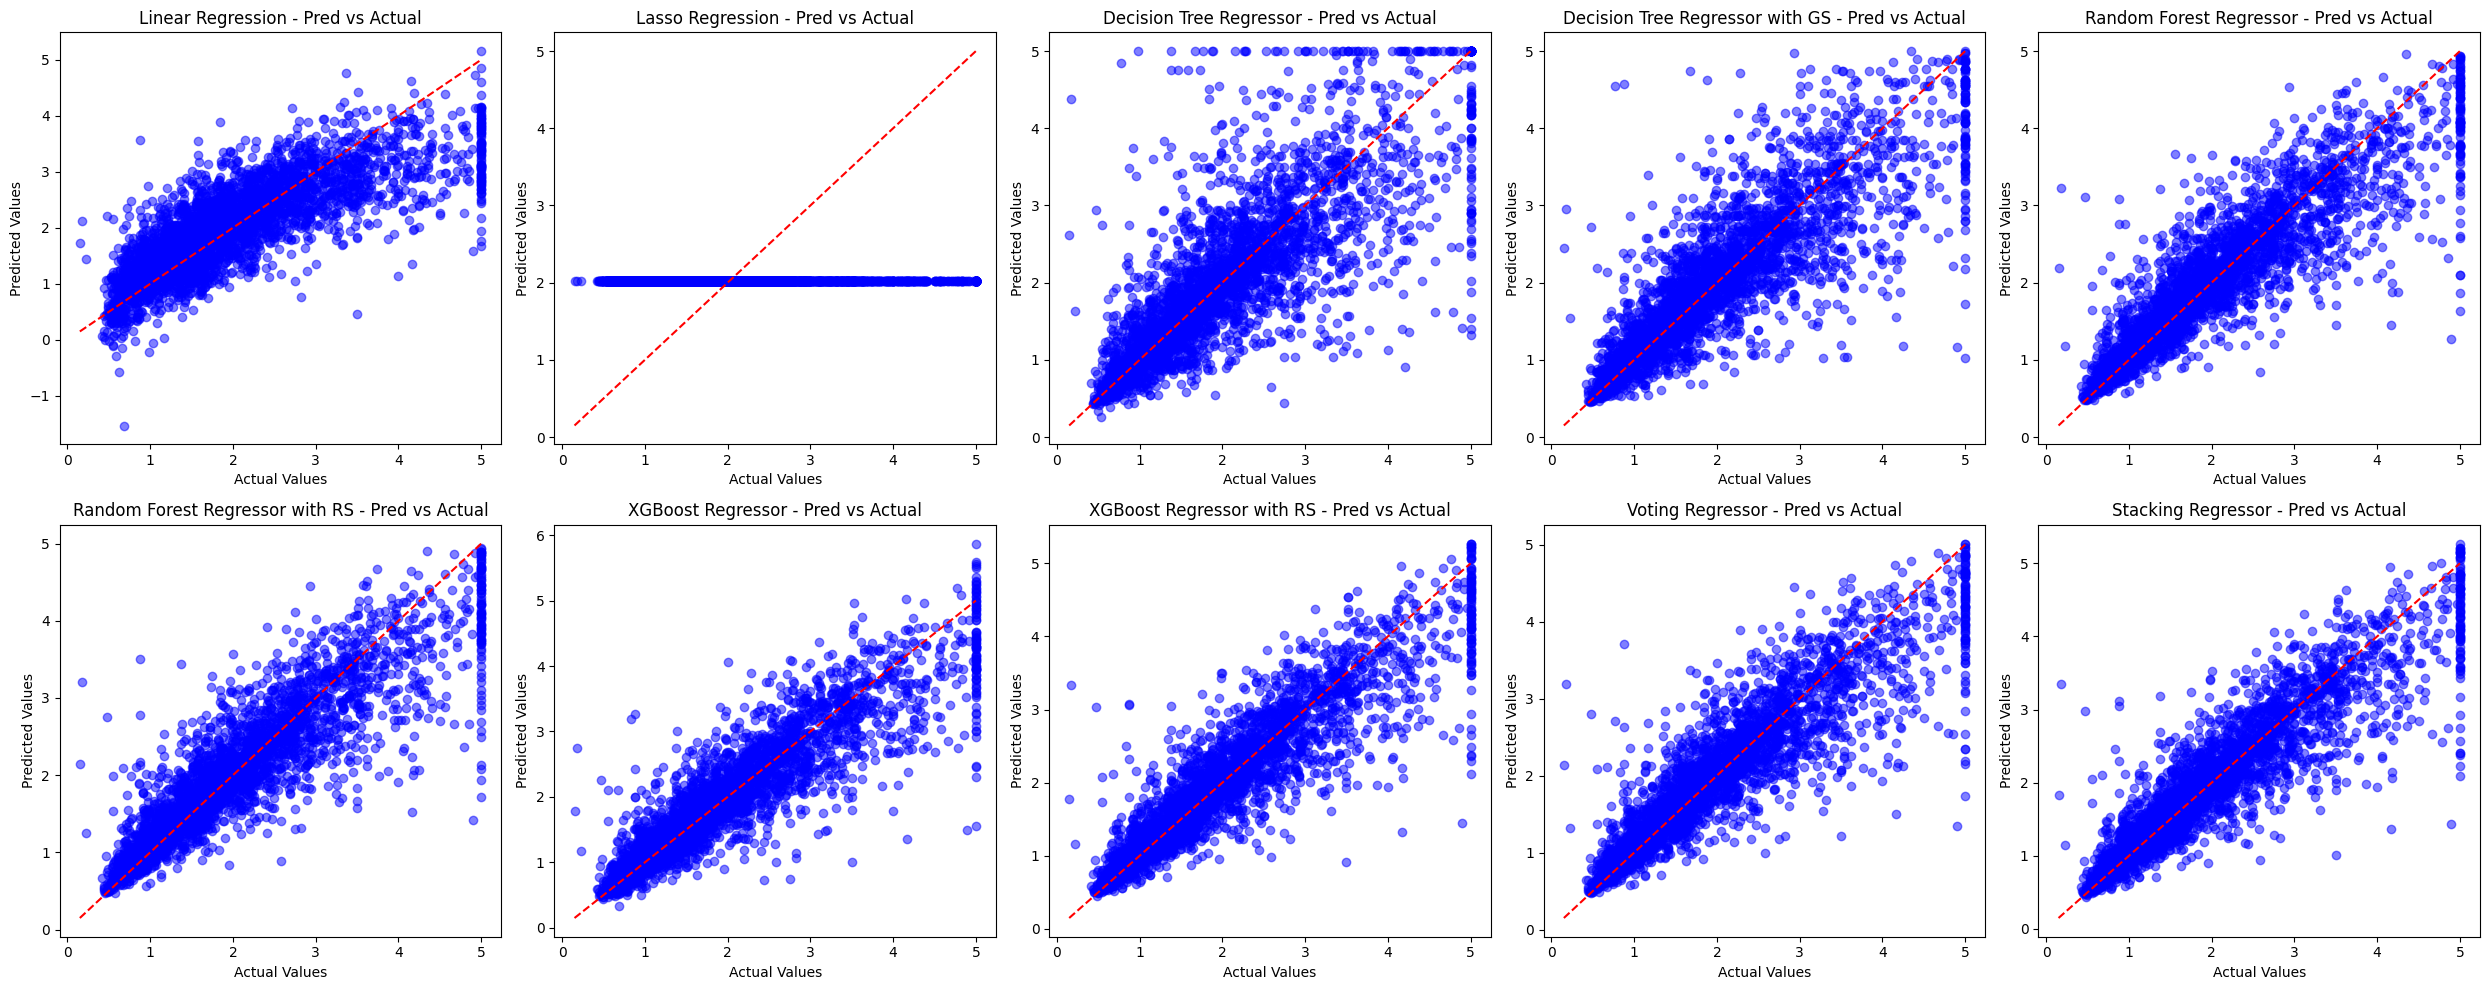

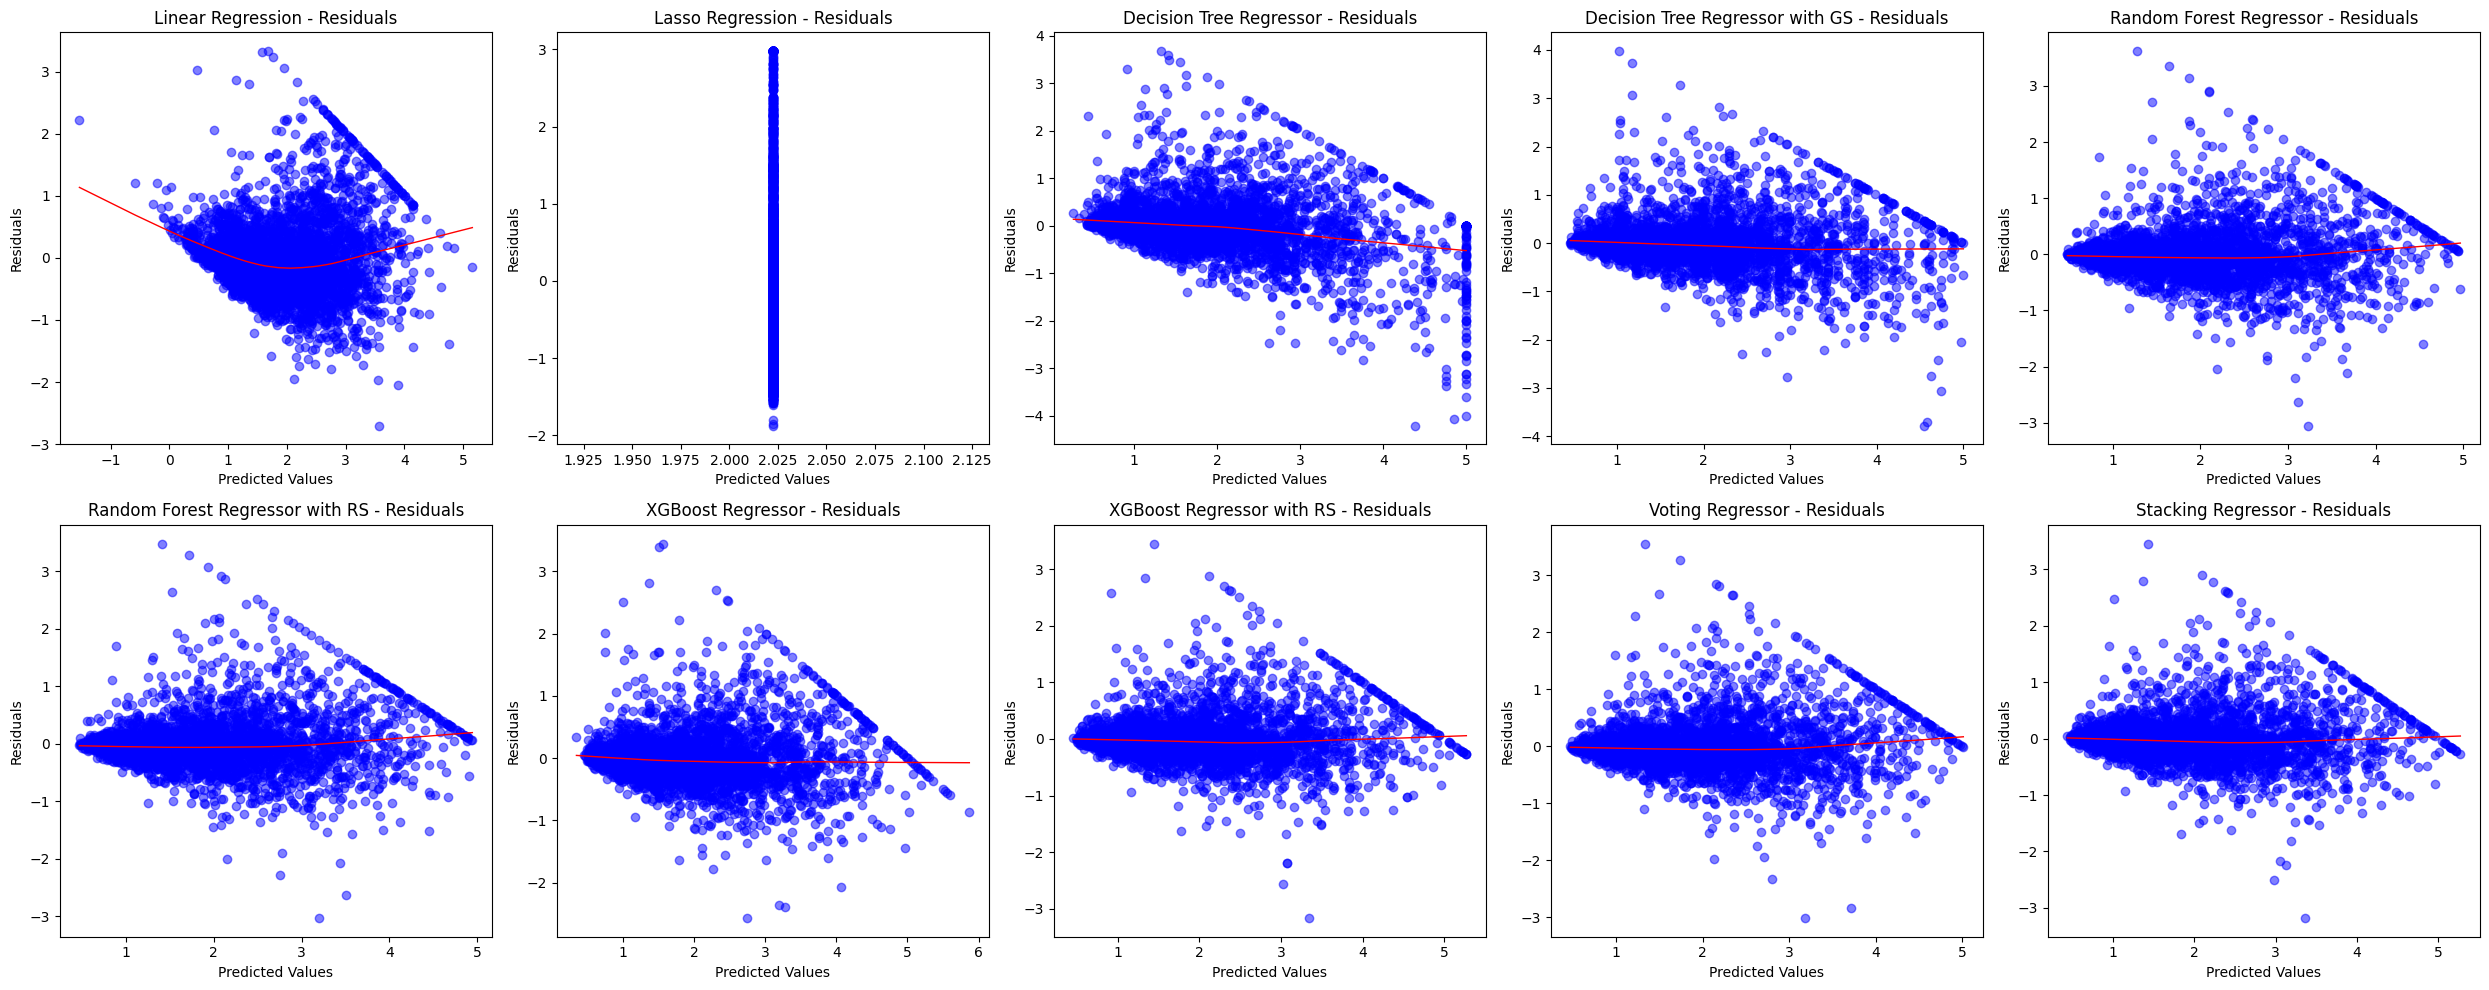

In [67]:
# Scatter plots of y_test vs y_pred for different models
fig, axes = plt.subplots(2, 5, figsize=(25, 10))  # Adjusted size for readability

# List of predictions and model names
model_predictions = [
    (y_test_pred_lr, 'Linear Regression'),
    (y_test_pred_lasso, 'Lasso Regression'),
    (y_test_pred_dt, 'Decision Tree Regressor'),
    (y_test_pred_dt_gs, 'Decision Tree Regressor with GS'),
    (y_test_pred_rf, 'Random Forest Regressor'),
    (y_test_pred_rf_rs, 'Random Forest Regressor with RS'),
    (y_test_pred_xgb, 'XGBoost Regressor'),
    (y_test_pred_xgb_rs, 'XGBoost Regressor with RS'),
    (y_test_pred_voting, 'Voting Regressor'),
    (y_test_pred_stacking, 'Stacking Regressor')
]

# Loop through each model and plot scatter of Predicted vs Actual
for i, (y_pred, model_name) in enumerate(model_predictions):
    axes[i // 5, i % 5].scatter(y_test, y_pred, color='blue', alpha=0.5)
    axes[i // 5, i % 5].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Line of perfect predictions
    axes[i // 5, i % 5].set_xlabel('Actual Values')
    axes[i // 5, i % 5].set_ylabel('Predicted Values')
    axes[i // 5, i % 5].set_title(f'{model_name} - Pred vs Actual')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

# Residual plots for each model
fig, axes = plt.subplots(2, 5, figsize=(25, 10))  # Adjusted size for readability

# Loop through each model and plot residuals
for i, (y_pred, model_name) in enumerate(model_predictions):
    residuals = y_test - y_pred

    # Plot residuals using seaborn scatterplot or regplot
    sns.regplot(x=y_pred, y=residuals, lowess=True, ax=axes[i // 5, i % 5], scatter_kws={'color': 'blue', 'alpha': 0.5}, line_kws={"color": "red", "lw": 1})

    axes[i // 5, i % 5].set_title(f'{model_name} - Residuals')
    axes[i // 5, i % 5].set_xlabel('Predicted Values')
    axes[i // 5, i % 5].set_ylabel('Residuals')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()
